In [1]:
import pandas as pd
import numpy as np
import math

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

/home/tyumen/saiga_8b/saiga_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]


In [6]:
df = pd.read_csv('ru_cefr_short_linguistic_features.csv')  
levels_df = pd.read_csv('ru_cefr_short.csv')
df['textbook-assigned cefr level'] = levels_df['textbook-assigned cefr level']
df = df.drop(columns=['text', 'level_number'])
df

,words,characters,unique_words,sentences,mean_len_word,median_len_word,median_len_sentence,mean_len_sentence,mean_len_word_in_syllables,percent_of_long_words,...,role_aux:pass_rel_text,role_nsubj:pass_rel_text,role_dep_rel_text,role_nummod:entity_rel_text,role_flat:foreign_rel_text,role_obl:agent_rel_text,role_list_rel_text,role_compound_rel_text,role_csubj:pass_rel_text,textbook-assigned cefr level
0,28,150,24,4,4.2,4.5,6.5,7.0,1.9,0.04,...,0.0,0.0,0.0,0.0,0.0,0.00,0,0.0,0.0,1
1,27,168,22,4,5.0,5.0,6.0,6.8,2.2,0.11,...,0.0,0.0,0.0,0.0,0.0,0.00,0,0.0,0.0,1
2,28,169,23,4,4.9,5.0,8.0,7.0,2.1,0.07,...,0.0,0.0,0.0,0.0,0.0,0.00,0,0.0,0.0,1
3,26,130,22,3,3.8,4.0,7.0,8.7,2.0,0.08,...,0.0,0.0,0.0,0.0,0.0,0.00,0,0.0,0.0,1
4,28,171,23,4,4.8,5.5,7.5,7.0,2.2,0.11,...,0.0,0.0,0.0,0.0,0.0,0.00,0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7317,27,218,27,2,7.0,8.0,13.5,13.5,3.0,0.41,...,0.0,0.0,0.0,0.0,0.0,0.00,0,0.0,0.0,6
7318,27,178,26,1,5.4,5.0,27.0,27.0,2.5,0.26,...,0.0,0.0,0.0,0.0,0.0,0.00,0,0.0,0.0,6
7319,30,213,28,2,5.9,4.5,14.5,15.0,2.8,0.37,...,0.0,0.0,0.0,0.0,0.0,0.00,0,0.0,0.0,6
7320,20,192,18,2,8.5,8.0,10.0,10.0,3.8,0.55,...,0.0,0.0,0.0,0.0,0.0,0.00,0,0.0,0.0,6


# Классификация

In [7]:
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    # ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Classifier', CatBoostClassifier(random_state=42, verbose=False)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Naive Bayes', GaussianNB()),
    ('XGBoost', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1, n_estimators=100))
]

In [8]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

## Классификация. С1 и С2 раздельно

In [9]:
y = df['textbook-assigned cefr level'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['textbook-assigned cefr level']), y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [11]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [12]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded)

        y_pred_original = le.inverse_transform(model.predict(X_test_scaled))

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: XGBoost
Обработка: LightGBM


In [13]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,CatBoost Classifier,0.562457,0.562457,0.503776,0.558393,0.553584
1,8,LightGBM,0.550853,0.550853,0.494613,0.546798,0.576792
2,0,Logistic Regression,0.542662,0.542662,0.480168,0.538061,0.581570
3,4,SVM,0.544710,0.544710,0.467564,0.536725,0.580205
4,7,XGBoost,0.534471,0.534471,0.479161,0.530566,0.594539
5,2,Random Forest,0.531741,0.531741,0.455839,0.525803,0.591126
6,5,K-Nearest Neighbors,0.434130,0.434130,0.372603,0.422783,0.754266
7,1,Decision Tree,0.395904,0.395904,0.360330,0.395880,0.843003
8,6,Naive Bayes,0.135836,0.135836,0.100265,0.073716,1.739249


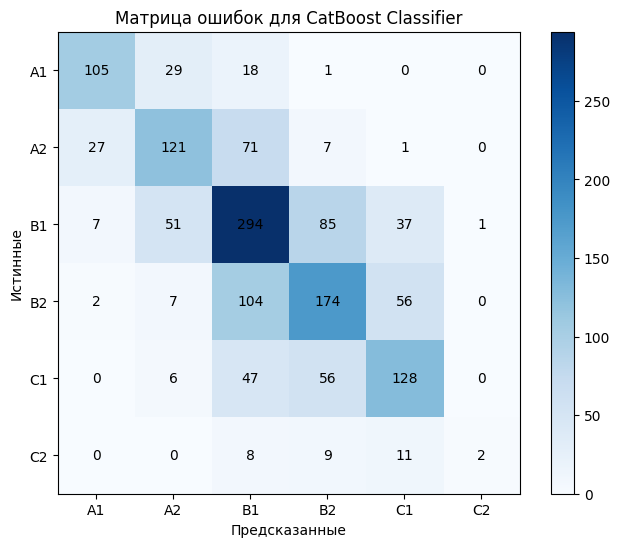

In [14]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

## Классификация. С1 и С2 вместе

In [15]:
y = df['textbook-assigned cefr level'].replace(6, 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['textbook-assigned cefr level']), y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [16]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [17]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded)

        y_pred_original = le.inverse_transform(model.predict(X_test_scaled))

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: XGBoost
Обработка: LightGBM


In [18]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,8,LightGBM,0.565188,0.565188,0.579648,0.564549,0.550853
1,3,CatBoost Classifier,0.565188,0.565188,0.578162,0.563685,0.545392
2,7,XGBoost,0.556997,0.556997,0.572035,0.556269,0.565870
3,4,SVM,0.556314,0.556314,0.567639,0.553412,0.557679
4,0,Logistic Regression,0.554949,0.554949,0.566188,0.552776,0.552901
5,2,Random Forest,0.550171,0.550171,0.559371,0.549590,0.562457
6,5,K-Nearest Neighbors,0.432082,0.432082,0.441357,0.423589,0.747440
7,1,Decision Tree,0.408874,0.408874,0.412472,0.408815,0.808874
8,6,Naive Bayes,0.243686,0.243686,0.198980,0.172991,1.471672


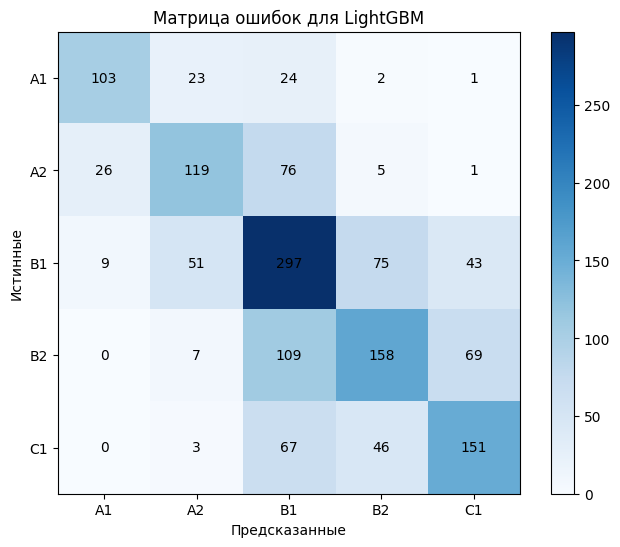

In [19]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

# Регрессия

In [20]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    # ('Random Forest', RandomForestRegressor(random_state=42, max_depth=5)),
    # ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Regressor', CatBoostRegressor(random_state=42, verbose=False)),
    ('SVM', SVR()),
    ('K-Nearest Neighbors', KNeighborsRegressor()),
    # ('Naive Bayes', GaussianNB()),
    ('XGBoost', XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMRegressor(random_state=42, verbose=-1, n_estimators=100))
]

## Регрессия. С1 и С2 раздельно

In [21]:
y = df['textbook-assigned cefr level'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['textbook-assigned cefr level']), y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [22]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [23]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, round_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if round_type == 'math':
        y_pred = [round(i) for i in y_pred]
    elif round_type == 'ceil':
        y_pred = [math.ceil(i) for i in y_pred] 
    elif round_type == 'floor':
        y_pred = [math.floor(i) for i in y_pred] 

    y_pred = np.clip(y_pred, 1, 6).tolist()

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

### Математическое округление

In [24]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'math')

        y_pred = model.predict(X_test_scaled)
        y_pred = [round(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'math')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [25]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,6,LightGBM,0.510580,0.510580,0.434500,0.505863,0.573379
1,5,XGBoost,0.505119,0.505119,0.443573,0.501659,0.587713
2,2,CatBoost Regressor,0.505802,0.505802,0.422122,0.498293,0.568601
3,3,SVM,0.503754,0.503754,0.419666,0.496035,0.577474
4,0,Linear Regression,0.479863,0.479863,0.404130,0.472318,0.605461
5,4,K-Nearest Neighbors,0.443686,0.443686,0.364169,0.430595,0.655973
6,1,Decision Tree,0.422526,0.422526,0.389362,0.422755,0.796587


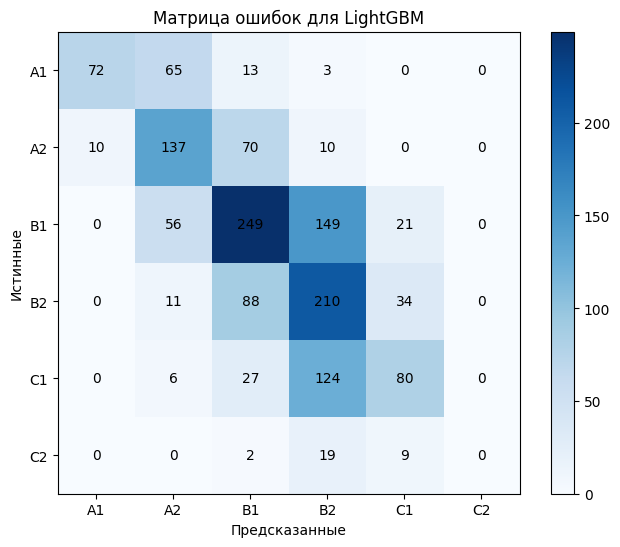

In [26]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вверх

In [27]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'ceil')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.ceil(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'ceil')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [28]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,1,Decision Tree,0.422526,0.422526,0.389362,0.422755,0.796587
1,2,CatBoost Regressor,0.394539,0.394539,0.312434,0.377445,0.724232
2,3,SVM,0.389078,0.389078,0.314186,0.374317,0.734471
3,4,K-Nearest Neighbors,0.384300,0.384300,0.304474,0.370666,0.750171
4,5,XGBoost,0.370648,0.370648,0.312260,0.364851,0.765188
5,0,Linear Regression,0.376792,0.376792,0.303107,0.362802,0.761775
6,6,LightGBM,0.378157,0.378157,0.287025,0.353084,0.736519


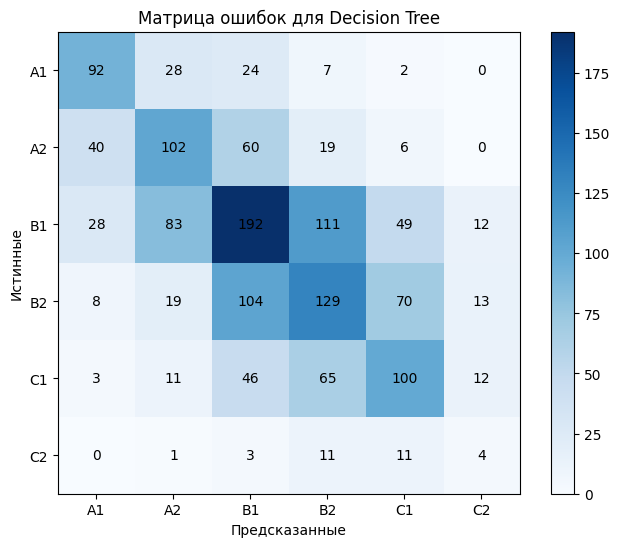

In [29]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вниз

In [30]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'floor')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.floor(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'floor')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [31]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,1,Decision Tree,0.422526,0.422526,0.389362,0.422755,0.796587
1,5,XGBoost,0.419113,0.419113,0.348041,0.399069,0.726962
2,6,LightGBM,0.430717,0.430717,0.336182,0.392085,0.692833
3,0,Linear Regression,0.412287,0.412287,0.343921,0.390625,0.722184
4,2,CatBoost Regressor,0.415700,0.415700,0.333593,0.383858,0.707167
5,3,SVM,0.414334,0.414334,0.330069,0.379960,0.718089
6,4,K-Nearest Neighbors,0.404778,0.404778,0.321540,0.371190,0.760410


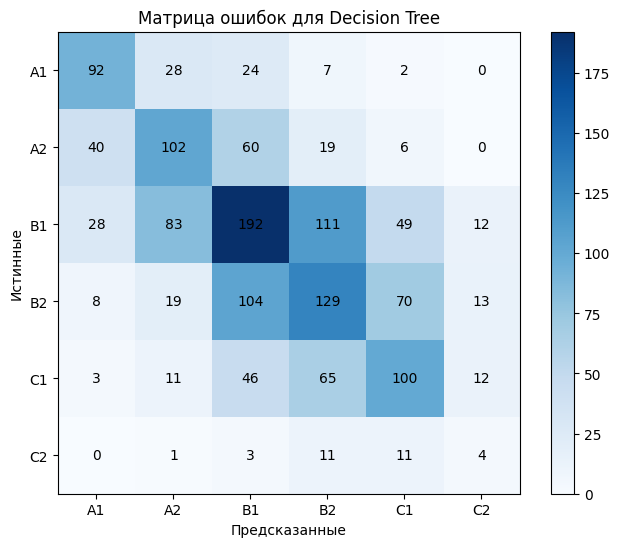

In [32]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

## Регрессия. С1 и С2 вместе

In [33]:
y = df['textbook-assigned cefr level'].replace(6, 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['textbook-assigned cefr level']), y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [34]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [35]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, round_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if round_type == 'math':
        y_pred = [round(i) for i in y_pred]
    elif round_type == 'ceil':
        y_pred = [math.ceil(i) for i in y_pred] 
    elif round_type == 'floor':
        y_pred = [math.floor(i) for i in y_pred] 

    y_pred = np.clip(y_pred, 1, 5).tolist()

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

### Математическое округление

In [36]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'math')

        y_pred = model.predict(X_test_scaled)
        y_pred = [round(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'math')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [37]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,SVM,0.504437,0.504437,0.499202,0.500423,0.556314
1,5,XGBoost,0.499659,0.499659,0.506938,0.499815,0.570648
2,6,LightGBM,0.497611,0.497611,0.495187,0.492764,0.560410
3,2,CatBoost Regressor,0.494881,0.494881,0.484857,0.488297,0.555631
4,0,Linear Regression,0.489420,0.489420,0.473079,0.484787,0.576792
5,4,K-Nearest Neighbors,0.439590,0.439590,0.427542,0.425869,0.642321
6,1,Decision Tree,0.400000,0.400000,0.411165,0.400400,0.804778


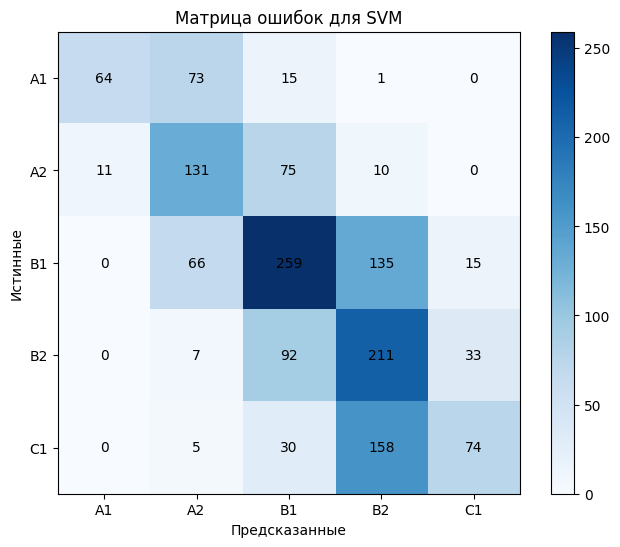

In [38]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вверх

In [39]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'ceil')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.ceil(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'ceil')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [40]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,1,Decision Tree,0.400000,0.400000,0.411165,0.400400,0.804778
1,5,XGBoost,0.408874,0.408874,0.392823,0.397774,0.715358
2,3,SVM,0.412287,0.412287,0.382269,0.397475,0.693515
3,6,LightGBM,0.416382,0.416382,0.373593,0.395298,0.690102
4,2,CatBoost Regressor,0.410922,0.410922,0.377034,0.394005,0.692150
5,0,Linear Regression,0.412969,0.412969,0.368087,0.393780,0.699659
6,4,K-Nearest Neighbors,0.397270,0.397270,0.372828,0.386992,0.724232


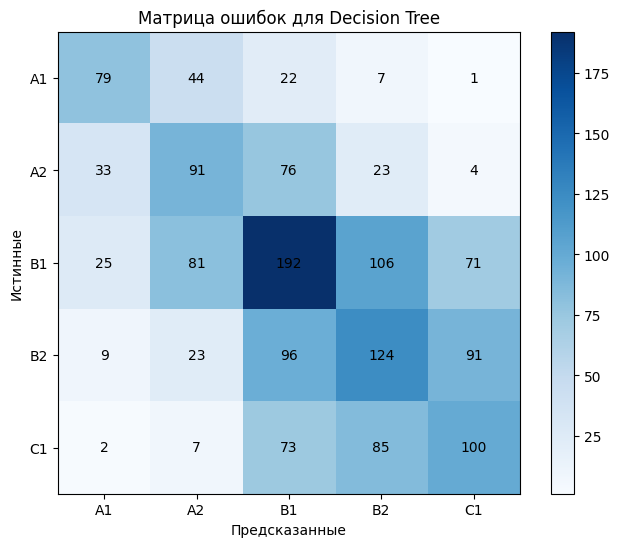

In [41]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вниз

In [42]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'floor')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.floor(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'floor')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [43]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,1,Decision Tree,0.400000,0.400000,0.411165,0.400400,0.804778
1,0,Linear Regression,0.408874,0.408874,0.402113,0.384659,0.707167
2,2,CatBoost Regressor,0.417065,0.417065,0.389527,0.379515,0.689420
3,3,SVM,0.414334,0.414334,0.394707,0.378663,0.696928
4,6,LightGBM,0.416382,0.416382,0.385875,0.376961,0.683959
5,5,XGBoost,0.401365,0.401365,0.383069,0.368601,0.726962
6,4,K-Nearest Neighbors,0.404096,0.404096,0.379746,0.367094,0.743345


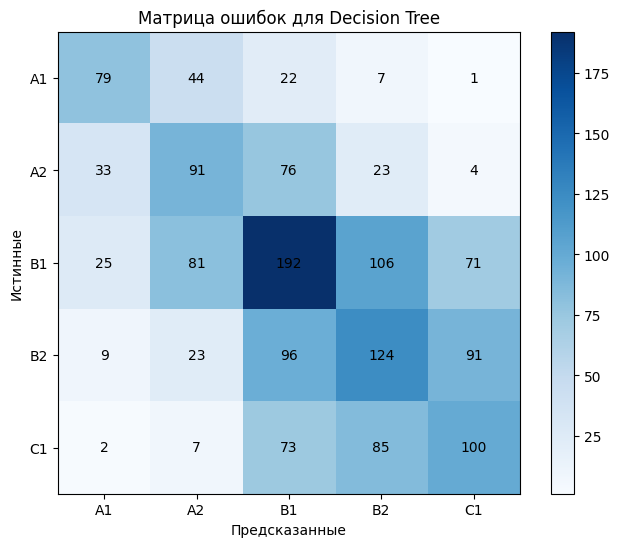

In [44]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()